# 미리랩 검증 보고서 — 세 가지 질문

**우리는 "미래를 맞혔나"를 검증하지 않습니다.** 미리랩은 예측기가 아니라 시뮬레이터니까요.
대신 세 가지를 물었습니다 ([검증 구조 문서](미리랩_검증구조_팀공유.md)):

| | 질문 | 결과 | 한 줄 사연 |
|---|---|---|---|
| **① 재료** | 시민 24명이 진짜 한국 인구를 닮았나? | ✅ **7/7 통과** | 깔끔하게 통과 |
| **② 작동** | 결과 차이를 만드는 게 페르소나인가? | ❌ 점수표 0/4 | **반전** — 시뮬이 채점 기준보다 똑똑해서 떨어짐 |
| **③ 한계** | 말도 안 되는 정책에도 상식을 지키나? | ❌ 4/6 (기준 5+) | 시험문제 결함 1 + 우리 예상이 틀림 1 |

**정직 원칙**: 기준은 실행 *전에* 박았고(`eval/prereg_validation.md`), 결과가 나빠도 점수를 고치지 않았습니다.
아래에서 그림과 시민들의 실제 발언으로 무슨 일이 있었는지 보여드립니다.

*(2026-06-07 · gemini-3-flash-preview · 시민 24명 × 288콜 · 약 $1)*

In [1]:
# 준비 — 저장된 결과 로드 (LLM 0콜, 키 불필요)
import json, sys
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
if not (ROOT / 'eval').exists():
    ROOT = ROOT.parent
EV = ROOT / 'eval'
sys.path.insert(0, str(ROOT))

pe = json.loads((EV / 'persona_eval.json').read_text(encoding='utf-8'))
ab = json.loads((EV / 'ablation_results.json').read_text(encoding='utf-8'))
rb = json.loads((EV / 'robustness_results.json').read_text(encoding='utf-8'))
cal = json.loads((EV / 'cost_calibration.json').read_text(encoding='utf-8'))
print('로드 완료 —', ab['config']['model'], '/', ab['config']['n'], '명 x', ab['config']['runs'], '회')

로드 완료 — gemini-3-flash-preview / 24 명 x 3 회


---
## ① 재료 검증 — "시민 24명이 한국 인구를 닮았나?"

**쉬운 말**: 전체 100만 명에서 아무나 24명을 뽑아도 분포는 조금씩 어긋나요.
그래서 "무작위로 24명 뽑기"를 **컴퓨터로 1만 번** 해보고, 그 정상 범위 안에 우리 24명이 들어 있는지 봤습니다.
나이·성별·지역·학력·혼인·가구·주거 **7개 전부 정상 범위 안** — 한쪽으로 쏠리지 않았어요.

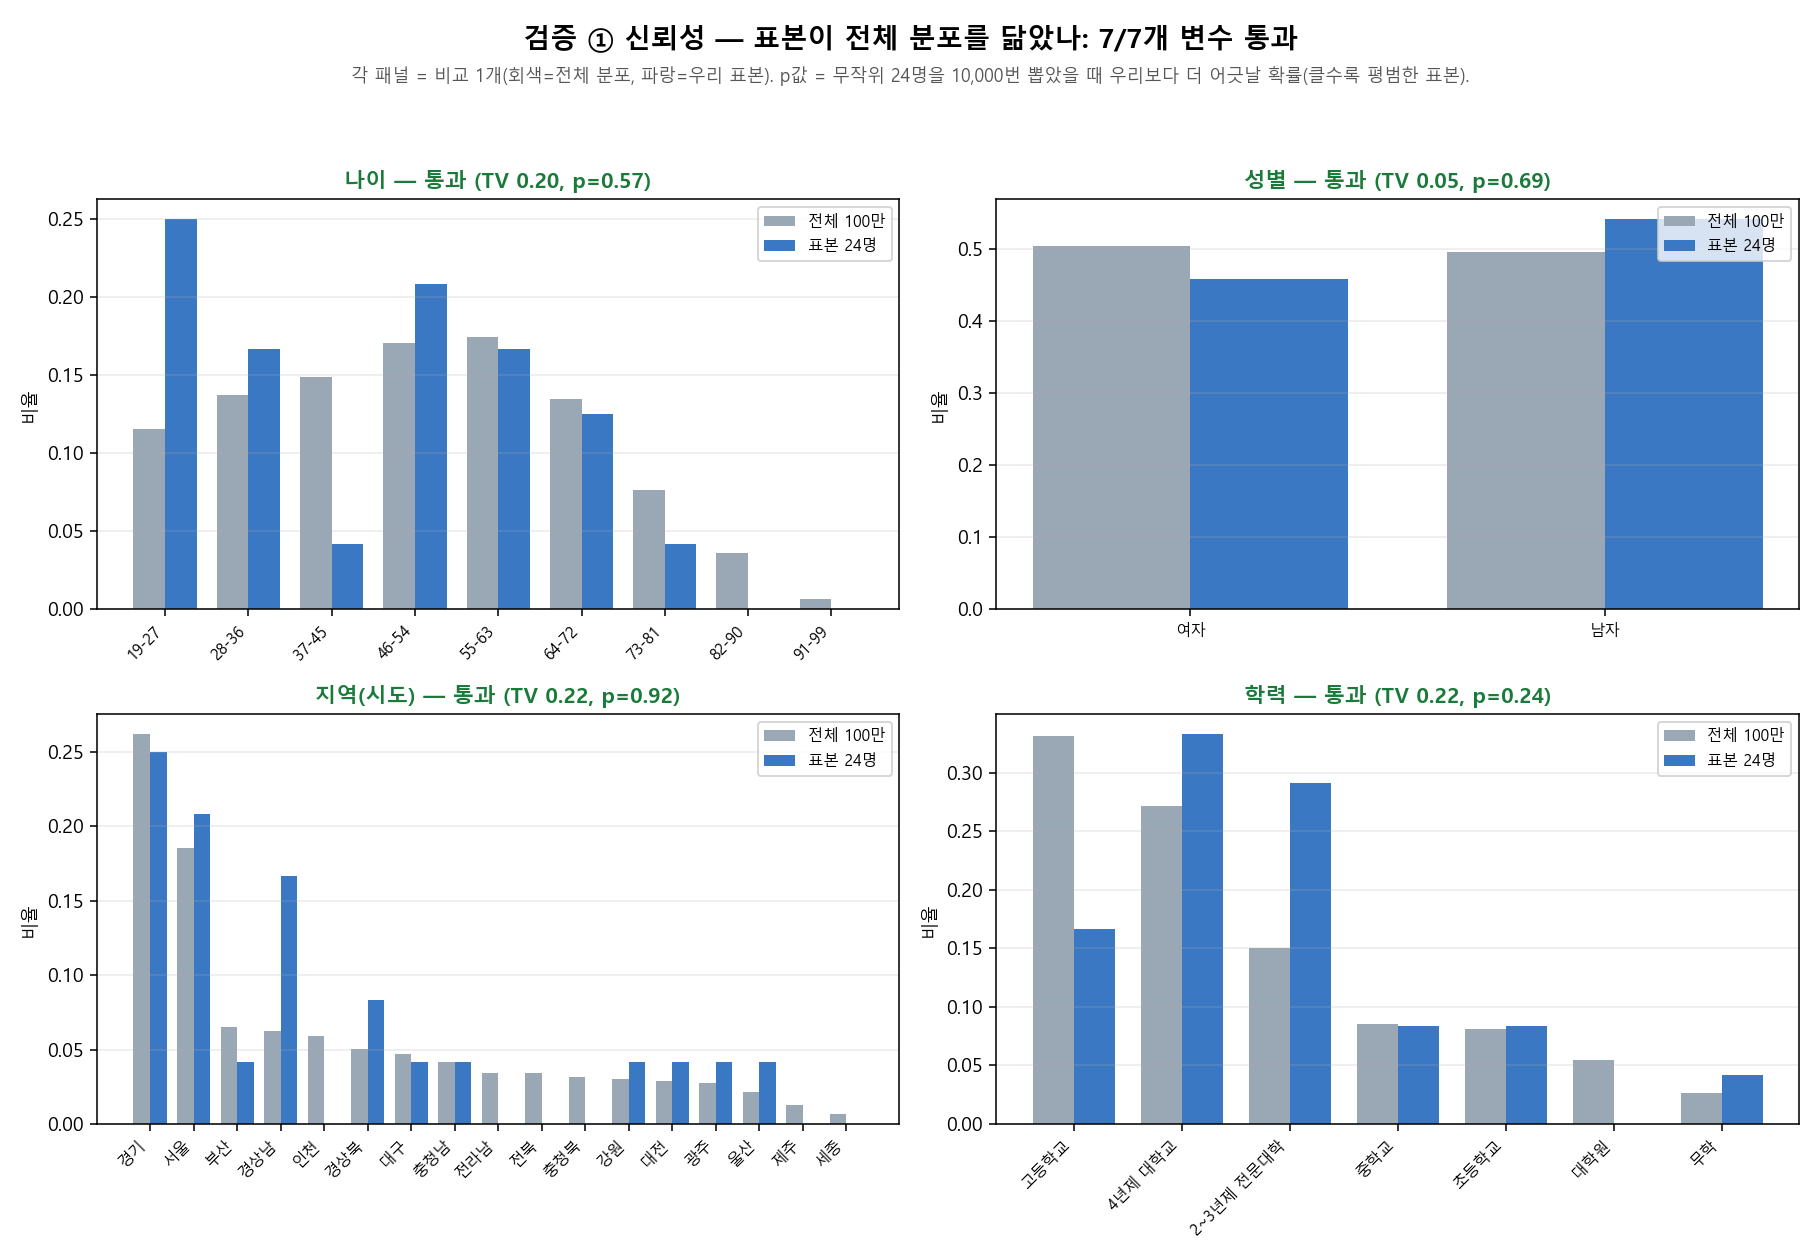

,변수,어긋난 정도(TV),무작위 1만 번의 평균,판정
0,나이,0.201600,0.215600,통과
1,성별,0.046100,0.081000,통과
2,지역(시도),0.219500,0.293700,통과
3,학력,0.221000,0.181100,통과
4,혼인 상태,0.159700,0.119500,통과
5,가구 형태,0.290800,0.298700,통과
6,주거 형태,0.140100,0.136500,통과


읽는 법: 우리 표본의 어긋남이 무작위 평균과 비슷하면 = 그냥 평범한 표본 = 통과.


In [2]:
display(Image(filename=str(EV / 'persona_eval_viz.png'), width=920))
df1 = pd.DataFrame([{'변수': r['label'],
                     '어긋난 정도(TV)': r['tv'],
                     '무작위 1만 번의 평균': r['boot_tv_mean'],
                     '판정': '통과' if r['pass'] else '쏠림 의심'} for r in pe['results']])
display(df1.style.map(lambda v: 'color:#1a7a3a;font-weight:bold' if v == '통과' else 'color:#b03030', subset=['판정']))
print('읽는 법: 우리 표본의 어긋남이 무작위 평균과 비슷하면 = 그냥 평범한 표본 = 통과.')

**데이터셋 자체는 믿을 만한가?** 이건 제작사(NVIDIA)가 이미 검증해서 공개했어요 — 통계청(KOSIS)·대법원·건보공단 등 **공식 통계 기반**으로 합성했고, 고령층 성비(여:남 1.52배), 최다 성씨 김(21.5%) 같은 게 실제와 일치함을 카드에 문서화했습니다. 우리는 그걸 인용하고, "거기서 쏠림 없이 뽑았는가"만 우리가 검증한 거예요. *(상세: `eval/persona_eval.md` — 유도 필드의 한계 포함)*

---
## ② 작동 검증 — "결과 차이를 만드는 게 페르소나인가?"

**실험**: 같은 청년월세 정책을 두 가지로 물었어요.
- **ON**: "당신은 이런 사람입니다" 인물 카드를 주고
- **OFF**: 카드 없이 익명 시민으로

카드가 있을 때만 답이 자기 처지를 따라가면, "결과를 만드는 건 페르소나"가 증명됩니다.

**점수표 결과는 0/4 탈락.** 그런데 원자료를 뜯어보니 — 떨어진 이유가 반전이었습니다.

In [3]:
# 판정 재계산 — 러너 함수 그대로 (드리프트 0)
_stdout = sys.stdout
import _run_validation_eval as V
sys.stdout = _stdout
from data.personas import load_personas, is_target
from sample_policies import SPECS

personas = load_personas(24, 42)
by_id = {p['id']: p for p in personas}
spec = SPECS['청년 월세 한시 특별지원']
ab_m = V.ablation_metrics(ab['rows'], personas)

easy2 = ['대상자와 비대상자의 점수가 갈리나', '점수가 자격 조건과 같은 방향인가',
         'ON이 OFF보다 다양하게 갈리나', '사람 간 차이가 호출 노이즈보다 큰가']
df2 = pd.DataFrame([{'#': c['id'], '묻는 것': e, '측정값': c['measured'],
                     '기준(사전등록)': c['criterion'],
                     '판정': '통과' if c['pass'] else 'FAIL'}
                    for c, e in zip(ab_m['checks'], easy2)])
display(df2.style.map(lambda v: 'color:#b03030;font-weight:bold' if v == 'FAIL' else 'color:#1a7a3a', subset=['판정']))

,#,묻는 것,측정값,기준(사전등록),판정
0,V1,대상자와 비대상자의 점수가 갈리나,ON 0.8 / OFF 1.1,ON ≥ 30 그리고 OFF < 15,FAIL
1,V2,점수가 자격 조건과 같은 방향인가,ON 0.231 / OFF -0.072,ON ≥ 0.5 그리고 차 ≥ 0.3,FAIL
2,V3,ON이 OFF보다 다양하게 갈리나,1.7 / 5.1 = 0.33,≥ 1.5,FAIL
3,V4,사람 간 차이가 호출 노이즈보다 큰가,1.7 / 2.95 = 0.58,≥ 2.0,FAIL


### 반전 — 시뮬이 채점 기준보다 똑똑했다

우리 채점 기준(`is_target`)은 **나이와 소득만** 보고 젊은 10명을 '대상자'라고 표시했어요.
그런데 시뮬 속 시민들은 정책 원문의 **숨은 조건들**(부모와 따로 살아야 함 · 무주택 · 소득 기준)까지 읽고,
10명 전원이 "나는 해당 안 됨"이라고 정확하게 답했습니다:

> 🗣 **천명준(19)**: "이거 부모님이랑 따로 살아야 주는 거잖아요. 저는 지금 집에서 살고 있어서 아예 해당이 안 될 텐데..."
>
> 🗣 **심석현(26)**: "저는 지금 자가로 되어 있어서 해당이 안 되네요. 기사 끝에 보니까 주택 소유자는 제외라고 딱 적혀 있어요."
>
> 🗣 **조유정(31)**: "소득 기준이 중위소득 60%면 생각보다 되게 낮거든요. 저처럼 평범하게 직장 다니는 사람들은 기준에서 다 걸릴 거예요."

실제 청년월세도 신청자 3명 중 2명이 요건 탈락했어요(국정감사). **시뮬이 현실을 맞게 재현했는데, 우리 채점표가 그걸 몰랐던 겁니다.**
이 풀엔 '진짜 수혜자'(독립거주 무주택 저소득 청년)가 0명이라, "사람마다 갈리는가"를 재는 점수가 의미를 잃었어요.

### 그럼 페르소나 효과는 없었나? — 아니요, 더 강하게 나왔습니다

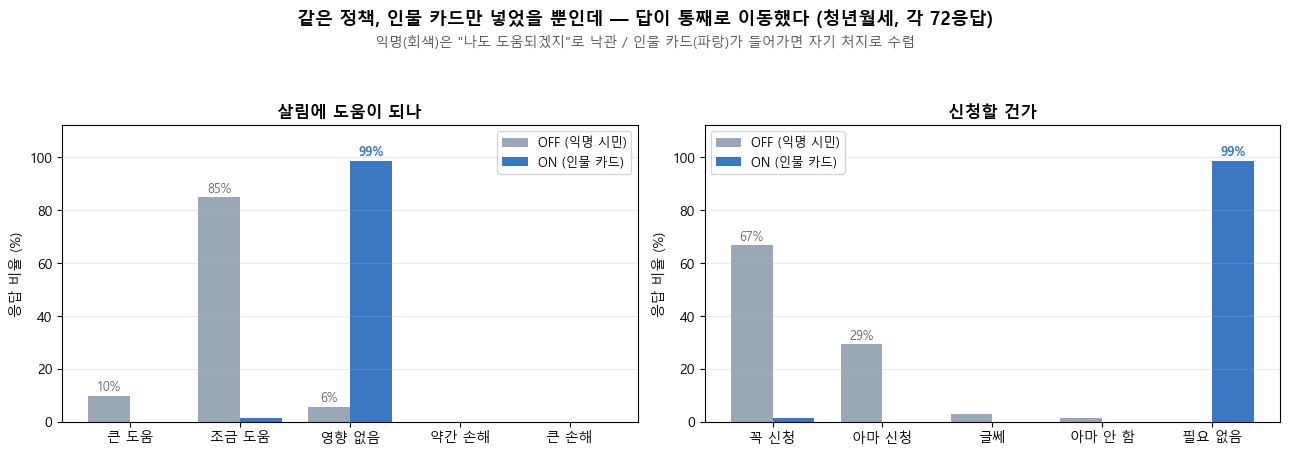

이 "통째 이동"이야말로 페르소나 효과의 직접 증거 — 다만 사전등록한 점수(분산 기반)가 아니라
부검에서 나온 증거이므로, 점수표는 0/4 그대로 둡니다. (도구 재설계 후 재실험은 별도 결정)


In [4]:
# 핵심 그림: 카드를 넣었을 뿐인데 — 답이 통째로 이동
rows_on = [r for r in ab['rows'] if r['cond'] == 'on' and r['ok']]
rows_off = [r for r in ab['rows'] if r['cond'] == 'off' and r['ok']]

BEN = [('big_help', '큰 도움'), ('some_help', '조금 도움'), ('no_effect', '영향 없음'),
       ('slight_loss', '약간 손해'), ('big_loss', '큰 손해')]
INT = [('surely', '꼭 신청'), ('probably', '아마 신청'), ('unsure', '글쎄'),
       ('probably_not', '아마 안 함'), ('no_need', '필요 없음')]

def pcts(rows, field, keys):
    c = Counter(r['survey'].get(field) for r in rows)
    n = sum(c.values())
    return [100 * c.get(k, 0) / n for k, _ in keys]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, field, keys, t in ((axes[0], 'benefit', BEN, '살림에 도움이 되나'),
                           (axes[1], 'intent', INT, '신청할 건가')):
    on_v, off_v = pcts(rows_on, field, keys), pcts(rows_off, field, keys)
    x = range(len(keys))
    w = 0.38
    ax.bar([i - w/2 for i in x], off_v, w, color='#9aa7b5', label='OFF (익명 시민)')
    ax.bar([i + w/2 for i in x], on_v, w, color='#3b78c3', label='ON (인물 카드)')
    for i in x:
        if off_v[i] >= 3: ax.text(i - w/2, off_v[i] + 2, f'{off_v[i]:.0f}%', ha='center', fontsize=9, color='#667')
        if on_v[i] >= 3: ax.text(i + w/2, on_v[i] + 2, f'{on_v[i]:.0f}%', ha='center', fontsize=9, color='#3b78c3', fontweight='bold')
    ax.set_xticks(list(x)); ax.set_xticklabels([lab for _, lab in keys], fontsize=10)
    ax.set_ylim(0, 112); ax.set_ylabel('응답 비율 (%)')
    ax.set_title(t, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.25)
fig.suptitle('같은 정책, 인물 카드만 넣었을 뿐인데 — 답이 통째로 이동했다 (청년월세, 각 72응답)',
             fontsize=13, fontweight='bold')
fig.text(0.5, 0.9, '익명(회색)은 "나도 도움되겠지"로 낙관 / 인물 카드(파랑)가 들어가면 자기 처지로 수렴',
         ha='center', fontsize=10, color='#555')
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()
print('이 "통째 이동"이야말로 페르소나 효과의 직접 증거 — 다만 사전등록한 점수(분산 기반)가 아니라')
print('부검에서 나온 증거이므로, 점수표는 0/4 그대로 둡니다. (도구 재설계 후 재실험은 별도 결정)')

---
## ③ 한계 검증 — "말도 안 되는 정책에도 상식을 지키나?"

**실험**: 금액만 다른 쌍둥이 정책 두 개를 넣었어요 — **전 국민 10억 원** (천장) vs **전 국민 1원** (바닥).
10억엔 "받긴 받는데 이게 말이 되나" 해야 하고, 1원엔 시큰둥해야 정상이라고 **예상**했습니다. 결과는 4/6:

,#,묻는 것,측정값,기준(사전등록),판정
0,R1,"10억: 거의 전원 ""내가 대상""이라 하나",100.0%,≥ 80%,통과
1,R2,10억: 혜택이 크다고 보나,91.7%,≥ 50%,통과
2,R3,10억: 불안·의심이 같이 오나,천장 29.7 vs 바닥 82.1,천장 > 바닥 그리고 천장 ≥ 20,FAIL
3,R4,1원: 의미 없다고 보나,100.0%,≥ 70%,통과
4,R5,1원: 굳이 안 움직이나,50.0%,≤ 20%,FAIL
5,R6,10억 의향 > 1원 의향인가,100.0% vs 50.0%,부등호 성립,통과


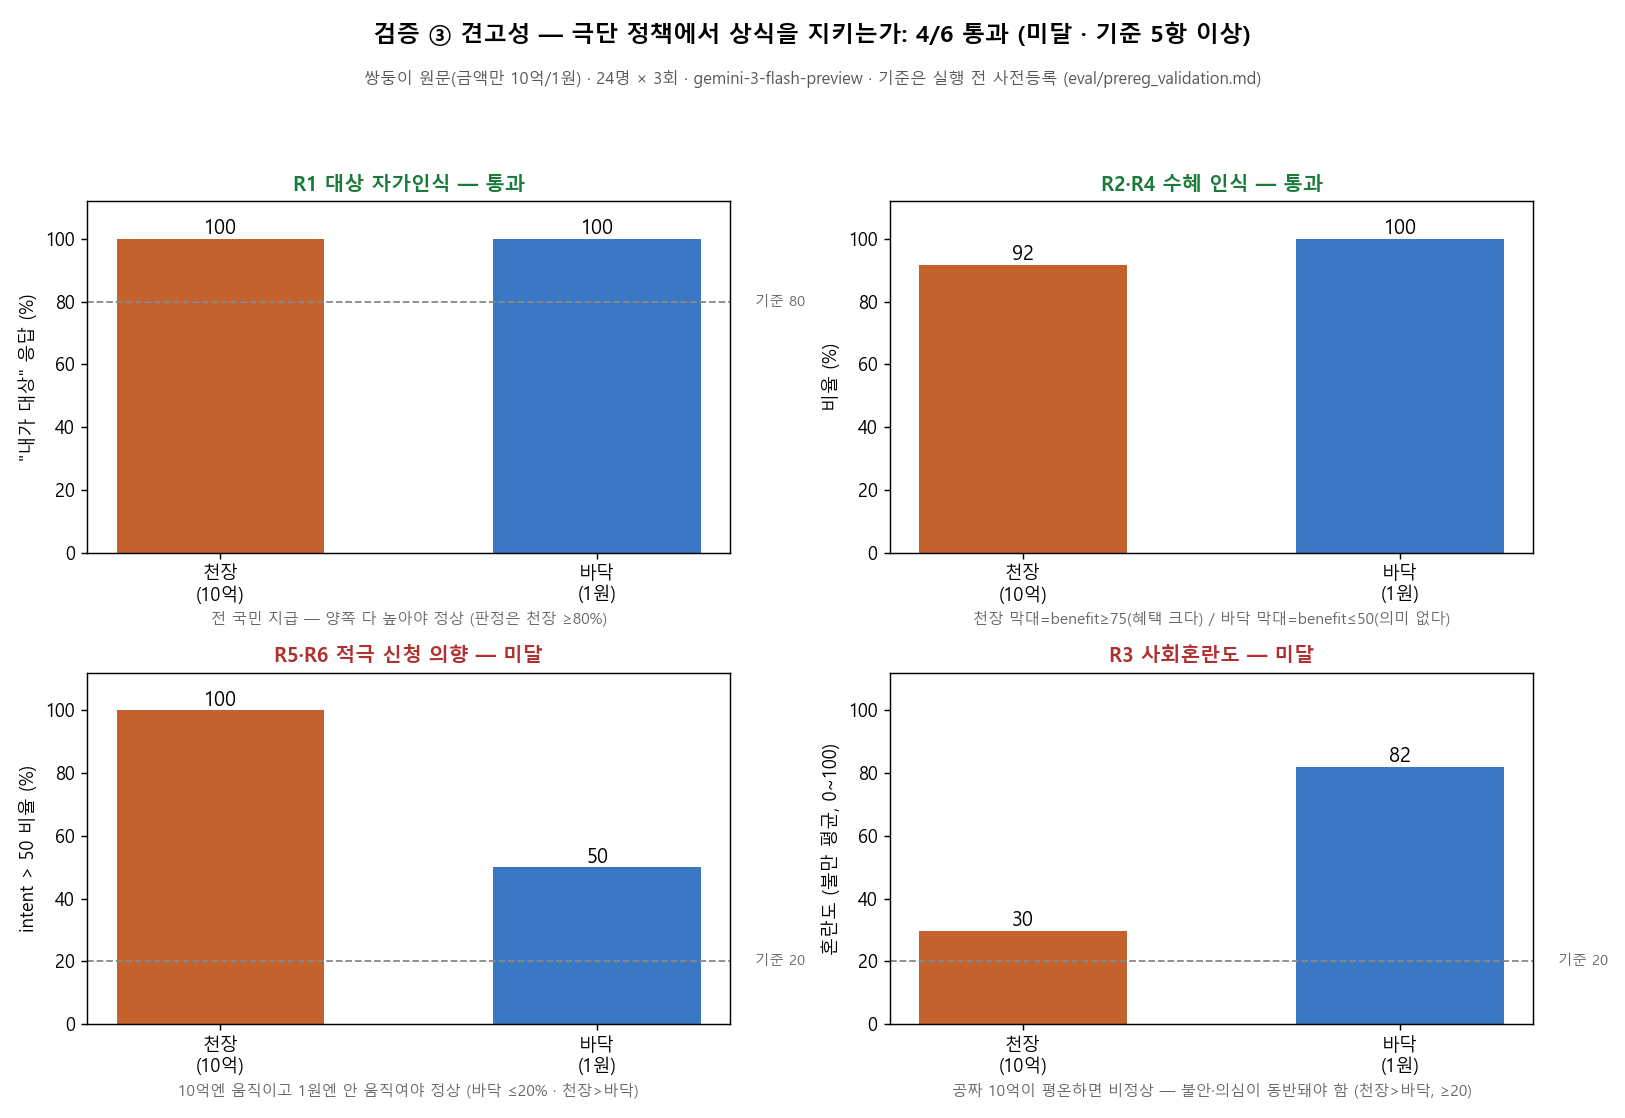

In [5]:
rb_m = V.robustness_metrics(rb['rows'], rb['config']['runs'])
easy3 = ['10억: 거의 전원 "내가 대상"이라 하나', '10억: 혜택이 크다고 보나',
         '10억: 불안·의심이 같이 오나', '1원: 의미 없다고 보나',
         '1원: 굳이 안 움직이나', '10억 의향 > 1원 의향인가']
df3 = pd.DataFrame([{'#': c['id'], '묻는 것': e, '측정값': c['measured'],
                     '기준(사전등록)': c['criterion'],
                     '판정': '통과' if c['pass'] else 'FAIL'}
                    for c, e in zip(rb_m['checks'], easy3)])
display(df3.style.map(lambda v: 'color:#b03030;font-weight:bold' if v == 'FAIL' else 'color:#1a7a3a', subset=['판정']))
display(Image(filename=str(EV / 'robustness_viz.png'), width=880))

### 떨어진 2개의 사연

**R5 — 우리가 만든 시험문제의 결함.** 쌍둥이 원문에 "신청 절차 없이 자동 입금"이라고 써버려서,
"신청할 건가요?" 문항이 망가졌어요. 시민들은 "어차피 자동으로 들어온다니 그냥 두지"라고 답했고,
그게 절반은 '꼭 신청(받음)', 절반은 '필요 없음'으로 기록됐습니다. 같은 무관심이 두 칸으로 갈라진 것.

**R3 — 우리 예상이 틀렸습니다.** "1원이면 무관심하겠지"라고 예상했는데, 시민들은 무관심하지 않았어요. **화를 냈습니다:**

> 🗣 **이준영(41, 공학자)**: "1원요? 전 국민한테 1원씩 보내려고 계좌 데이터 돌리는 전산 비용이랑 이체 수수료가 훨씬 더 나오겠는데요."
>
> 🗣 **신민재(24)**: "우리 가족 다 합쳐도 3원인데 이걸로 껌 한 통도 못 사잖아요. 진짜 왜 하는 건지 모르겠네요."

...생각해보면 진짜 사람들도 이러겠죠. **시뮬은 우리 예상보다 사람답게 반응했고, 사전등록 원칙대로 FAIL은 FAIL로 남깁니다.**

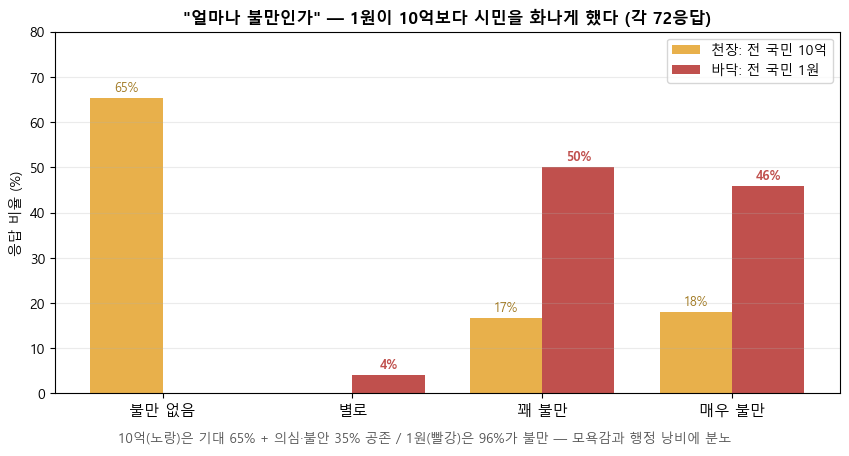

In [6]:
# 그림: 1원이 10억보다 시민을 화나게 했다
fl = [r for r in rb['rows'] if r['cond'] == 'floor' and r['ok']]
ce = [r for r in rb['rows'] if r['cond'] == 'ceiling' and r['ok']]
DIS = [('none', '불만 없음'), ('not_much', '별로'), ('somewhat', '꽤 불만'), ('very', '매우 불만')]

fig, ax = plt.subplots(figsize=(8.6, 4.4))
ce_v, fl_v = pcts(ce, 'dissatisfaction', DIS), pcts(fl, 'dissatisfaction', DIS)
x = range(len(DIS)); w = 0.38
ax.bar([i - w/2 for i in x], ce_v, w, color='#e8b04b', label='천장: 전 국민 10억')
ax.bar([i + w/2 for i in x], fl_v, w, color='#c0504d', label='바닥: 전 국민 1원')
for i in x:
    if ce_v[i] >= 3: ax.text(i - w/2, ce_v[i] + 1.5, f'{ce_v[i]:.0f}%', ha='center', fontsize=9, color='#a07820')
    if fl_v[i] >= 3: ax.text(i + w/2, fl_v[i] + 1.5, f'{fl_v[i]:.0f}%', ha='center', fontsize=9, color='#c0504d', fontweight='bold')
ax.set_xticks(list(x)); ax.set_xticklabels([lab for _, lab in DIS], fontsize=11)
ax.set_ylim(0, 80); ax.set_ylabel('응답 비율 (%)')
ax.set_title('"얼마나 불만인가" — 1원이 10억보다 시민을 화나게 했다 (각 72응답)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.25)
fig.text(0.5, -0.02, '10억(노랑)은 기대 65% + 의심·불안 35% 공존 / 1원(빨강)은 96%가 불만 — 모욕감과 행정 낭비에 분노',
         ha='center', fontsize=9.5, color='#555')
fig.tight_layout()
plt.show()

---
## 종합 — 세 줄 요약

1. **재료는 건전합니다** (①): 시민 24명은 한국 인구 분포에서 쏠림 없이 뽑혔어요. ✅
2. **페르소나가 결과를 만듭니다** (②): 익명이면 낙관으로 뭉개지고, 인물 카드가 들어가면 자기 처지로 수렴 — 다만 이 증거는 사전등록 점수가 아니라 부검에서 나왔으므로, 점수표는 **0/4 그대로** 둡니다.
3. **시뮬은 우리 예상보다 사람다웠습니다** (③): 숨은 자격 조건을 읽어내고, 모욕적인 정책에 화를 냈어요. 떨어진 항목들은 시뮬의 결함이 아니라 **검증 도구·예측의 결함**으로 진단 — 단 그 판단으로 점수를 바꾸지는 않았습니다.

**남은 일 (미결 — 결정 대기)**
- 검증 도구 고쳐서 재등록·재실험 (~$1): ② 채점 기준을 본문 요건 기반으로 / ③ 신청 절차 있는 원문 + "1원=무관심" 기대 수정
- 검증 구조 문서의 바닥 테스트 기대 문구 수정
- 알려진 측정 공백: '실현 기대' 문항(B′) — "안 믿지만 받으면 좋지"를 분리할 채널

**비용·캐시 (실측)**: 288콜, 입력 65.3만 토큰 중 **56%가 캐시 적중**(예상 밖 발견 — 같은 인물 카드가 12콜에서 재사용된 덕). 실비용 약 $1.

---
*재실험: `python _run_persona_eval.py`(① 0콜) · `python _run_validation_eval.py`(②③ 288콜) · `python _forensic_validation.py`(부검 0콜) · 이 노트북: `python -m nbconvert --to notebook --execute --inplace notebooks/검증보고서_3축.ipynb`*